VISUALIZZARE LE FEATURE MAPS: SBIRCIARE DENTRO LA SCATOLA NERA

Guardiamo attraverso gli occhi dell'intelligenza artificiale.
L'AI spesso è paragonata ad una scatola nera, luogo in cui i dati entrano ed escano senza che nessuno sappia cosa accade nel mezzo.
In realtà è possibile sbirciare dentro questa scatola nera, scoprendo che dietro al calcolo matematico si nasconde un progetto di visione quasi artistico.

- Estrazione degli output intermedi
- Tecnniche di plotting: trasformazione tensori di attivazone in griglie di immagini leggibili
- Analisi semantica: interpretare l'evoluzoine gerarchica dai bordi alle forme complesse.

Come possiamo catturare un segnale che sta viaggiando alla velocità della luce dentro i layer?

Accesso alle Rappresentazioni Interne
Estrarre le attivazioni senza alterare il modello
Il modello è una funzione che trasforma un input in una predizione finale. Per comprendere il comportamento di una CNN dobbiamo estrarre i dati attraverso i layer convoluzionali. Dobbiamo campionare i dati proprio mentre attraversano i layer convoluzionali, per capire che trasformazioni stanno subendo.
Il primo layer definisce i contorni, il secondo le ombre il terzo i dettagli, estrarre le attivazioni significa guardare ogni singolo layer separatamente senza aspettare di vedere l'immagine finale proiettata sullo schermo.
In Keras dobbiamo utilizzare l'API Funzionale per creare un nuovo modello che condivida i pesi con l'originale ma che restituisca come output le mappe di caratteristiche generate dai layer intermedi.

Modelli Multi-Output
Mappare l'input ai layer di interesse.
Per visualizzare l'iterno, dobbiamo creare un modello sonda, non modifichiamo quello originale, creiamo uno nuovo, un sub-modello, che ha lo stesso ingresso ma come output punta direttamente ai tensori intermedi tramite la proprieta layer output. Come se aprissimo un rubinetto a metà strada per prelevare un campione.
- Selezione dei layer: tramite la proprietà 'layer.output' possiamo isolare il tensore prodotto da qualsiasi livello della rete
- Instanzazione del sub-modello: creaiamo un oggetto 'Model' che accetta l'input originale e restituisce una lista di output intermedi.
- Condivisione dei pesi: il nuovo modello non richiede addestramento poichè punta direttamente agli strati interni del modello già addestrato.
- Il modella di visualizzazione permette di ottenere una lista di attivazioni per ogni layer selezionato mantenendo la coerenza pesi correnti.

Meccanica dell'Estrazione
Accesso tramite nome
E' possibile utilizzare model.get_layer(name).output per estrarre le attivazioni da layer specifici senza dover conoscere il loro indice numerico.
Il sub-modello richiede comunque un tensore a quattro dimensioni. Non basta passargli un'immagine, dobbiamo passare la dimesione del batch. Per visualizzare una singola immagine dobbiamo aggiungere una dimensione del batch tramite np.expand_dims
Una volta pronto, chiamiamo model.predict() sul sub-modello otteniamo un array NumPy che rappresentano l'intensità di attivazione di ogni filtro.

Perche Visualizzare?
In realtà visualizzare è la forma più alta di debugging.
Un modello può sembrare perfetto ma fallire nella realtà. Visualizzando le feature map puoi scoprire che la rete per riconoscere un gatto sta guardando la trama del tappeto su cui era seduto.

Adesso che abbiamo i dati dobbiamo rendereli visibili

Plotting delle Attivazioni
Un volta ottenuti gli array delle attivazioni dobbiamo decidere come rappresentarli. Ogni layer convoluzionale produce un volume tensoriale dove ogni cancale rappresenta una feature map specifica.

Visualizzazione dei Canali.
Rendering della mappe di caratteristiche.
- Formato delle mappe: un output ha forma 'Height x Width xChannels'. Iteriamo sui canali per visualizzare ogni mappa separatamente.
- Normalizzazione: poiche le attivazioni possono vedere valori molto diversi tra di loro, per una migliore visibilità è utile scalare i valori di attivazione in modo che coprano l'intero spettro di luminosità dell'immagine
- Colormaps: l'uso di mappe di colore come 'viridis' è fondamentele, aiuta a evidenziare le zone ad alta attivazione rispetto a quelle neutre. Colori caldi, come giallo, indicano qualcosa di importante, mentre colori freddi, come viola, indicano qualcosa di poco importante.
- La visualizzazione trasforma i array numerico in una matrice di intensità dove il valore indica la forza della risposta del filtro.

Gestione delle griglia
Dobbiamo gestire i subplots in modo dinamico
Calcoliamo il numeri di righe e colonne in base al numero di filtro dei layer per creare una panoramica completa delle attivazioni. Layer a 64 filtri, creiamo una griglia 8x8
Noteremo che man mano che procediamo nei layer (che scandiamo in prodondità) la risoluzione delle immagini delle mappe diminuisce a causa delle operazioni di pooling. Stiamo scambiando la precisione della predizione spaziale (dove si trova il pixel) con la ricchezza dell'informazione semantica (cos'è quel oggetto).
A differenza dell input non applichiamo denormalizzazione alle mappe poichè siamo interessati all intensità relativa del segnale neurale.

C'è una differenza enorme tra i pesi e le mappe di attivazione
I pesi sono i muscoli della rete, una volta addestrati rimangono fissi.
La mappe di attivazione sono la reazione di quei muscoli ad uno stimolo specifico.
I pesi ci dicono cosa le rete sa fare in generale, ma la feature map ci dicono cosa la rete sta vedendo in questa specifica immagine.

Interpretazione Gerarchica
Cosa vede davvero la rete?
La cosa interessante delle CNN e la loro natura gerarchica. Se guardi i primi layer vedi che la rete si comporta come un fotografo alle prime armi, si concentra sui bordi, sui contrasti, man mano che scendiamo iniziano ad emergere dei pattern, la rete sta smontando la realtà per capire come è costruita.
L'analisi delle attivazioni rivela come la CNN scomponga l informazione visiva. Nei primi layer la rete si comporta come un set di filtri fotografici per bordi e colori.
Man mano che scendiamo in profondità le mappe diventano meno leggibili per l'occhio umano ma più ricche di significato semantico per il classificatore finale.

- Layer iniziali: visualizziamo filtri di Gabor che reagiscono a orientamenti di linee texture semplici e contrasti luminosi. Mappe che si illuminano solo per le linee diagonali o per gradienti di luce.
- Layer intermedi: le mappe iniziano a isolare forme geometriche cerchi, angoli o pattern ripetitivi complessi. I bordi si combinano, due linnee diventano un angolo, due linee diventano un cerchio, ecc
- Layer profondi: le attivazioni diventano sparse e astratte identificando parti specifiche dell oggetto come occhi, ruote o ali. Qui accade la magia, le attivazioni identificano parti specifiche come la ruota di un auto o le ali di un uccello.
- La gerarchia visiva riflette l'aumento del campo ricettivo dei neuroni nei layer più profondi della rete.

Sparsità e Astrazione
Arrivati nei ultimi layer molte mappe potrebbero apparire completamente scure. Questo accade perchè quei filtri sono diventati estremamente specifici per pattern rari, mgari quel filtro reagisce solo alle piume di un pavone, se nell'immagine non c'è un pavone il filtro resta fermo.
L'astrazione semantica comporta la perdita della posizione esatta dei pixel a favore della compressione dellla presenza di un concetto visivo.
Attraverso la visualizzazione confermiamo che la rete impara a riconoscere una feature indipendentemente dalla sua posizione precisa nel frame.

Analogie con la corteccia visiva biologica
La tecnologia ha imitato la natura.
Il nostro cervello fa esattamente la stessa cosa, abbiamo neruoni che scaricano solo quando vedono un bordo verticale. Il modo più efficiente per comprendere immagini è partire dalla scomposizione più elementare, per poi ricostruire la complessità pezzo dopo pezzo.



Scaricando immagine da: https://picsum.photos/224/224...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


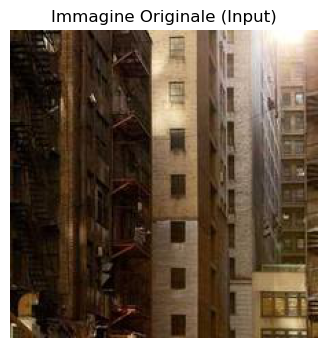

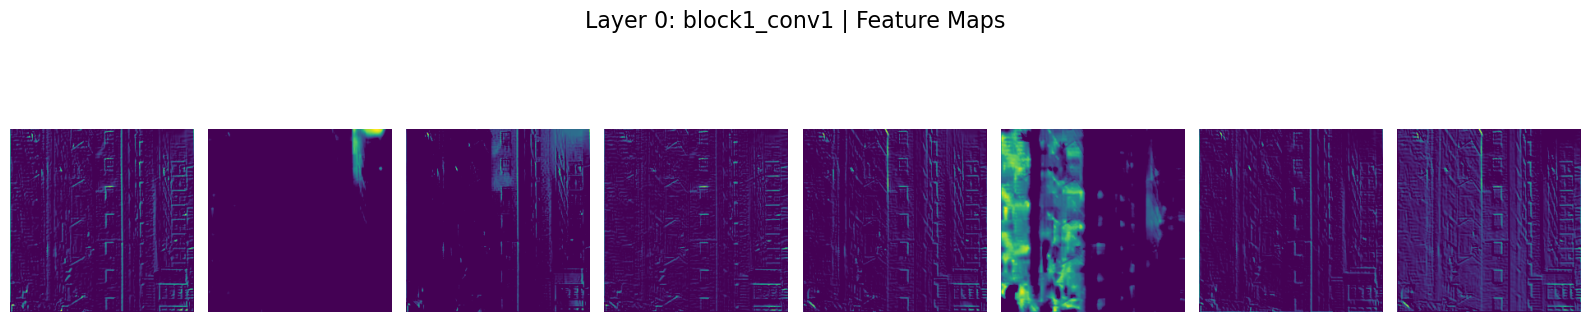

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
import keras
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.utils import img_to_array
from keras.models import Model

# --- 1. CARICAMENTO DEL MODELLO PRE-ADDESTRATO ---
# Carichiamo VGG16 addestrata su ImageNet. 
# include_top=False: Escludiamo i layer Fully Connected finali (il classificatore).
# Ci fermiamo all'ultimo layer convolutivo per usare la rete come Feature Extractor.
base_model = VGG16(weights='imagenet', include_top=False)

# --- 2. PIPELINE DI ACQUISIZIONE E PRE-PROCESSING ---
def download_random_image(url="https://picsum.photos/224/224"):
    """
    Gestisce il recupero di dati binari via HTTP e la conversione in formato immagine.
    """
    print(f"Scaricando immagine da: {url}...")
    # Recupero dei byte grezzi dall'URL
    response = requests.get(url)
    
    # BytesIO crea un buffer binario in memoria che simula un file aperto.
    # PIL.Image.open legge il buffer e riconosce il formato (JPG/PNG).
    # .convert('RGB') è fondamentale: garantisce che l'immagine abbia 3 canali 
    # (alcune immagini web potrebbero essere in scala di grigi o avere il canale Alpha).
    img = Image.open(BytesIO(response.content)).convert('RGB')
    
    # Resize necessario: VGG16 si aspetta input di dimensione $224 \times 224$.
    img = img.resize((224, 224))
    return img

# Esecuzione del download
img = download_random_image()

# Conversione da oggetto PIL a array NumPy per manipolazione numerica.
x = img_to_array(img)

# Batch Dimension Expansion: Keras si aspetta tensori di forma (Batch, Altezza, Larghezza, Canali).
# Trasformiamo l'array da (224, 224, 3) a (1, 224, 224, 3).
x = np.expand_dims(x, axis=0)

# Preprocessing specifico ImageNet: 
# 1. Sottrae la media dei pixel calcolata sull'intero dataset ImageNet.
# 2. Converte i canali da RGB a BGR (standard storico di Caffe/VGG).
x = preprocess_input(x)

# --- 3. CREAZIONE DEL MODELLO DI ISPEZIONE (Functional API) ---
# Vogliamo estrarre l'output dei primi 8 layer (Blocchi convolutivi 1 e 2).
# base_model.layers[0] è l'InputLayer (non produce trasformazioni).
# Partiamo dall'indice 1 per visualizzare le prime attivazioni reali.
layer_outputs = [layer.output for layer in base_model.layers[1:9]]

# Definiamo un nuovo modello che ha lo stesso input del base_model 
# ma restituisce una LISTA di output (uno per ogni layer selezionato).
activation_model = Model(inputs=base_model.input, outputs=layer_outputs)

# Eseguiamo il passaggio in avanti (Forward Pass). 
# 'activations' conterrà 8 array NumPy con le mappe di caratteristiche (Feature Maps).
activations = activation_model.predict(x)

# --- 4. FUNZIONE DI VISUALIZZAZIONE SCIENTIFICA ---
def plot_layer_activations(layer_num, layer_name, activation_data, n_features=8):
    """
    Visualizza i primi n filtri (canali) estratti da un determinato layer.
    """
    # Selezioniamo il tensore delle attivazioni per il layer desiderato
    layer_activation = activation_data[layer_num]
    
    plt.figure(figsize=(16, 4))
    plt.suptitle(f"Layer {layer_num}: {layer_name} | Feature Maps", fontsize=16)
    
    for i in range(n_features):
        plt.subplot(1, n_features, i + 1)
        # Visualizziamo il canale i-esimo (indice dell'ultima dimensione).
        # cmap='viridis': Mappa di colore percettivamente uniforme, standard nel 2025 
        # per evidenziare le intensità di attivazione dei neuroni.
        plt.imshow(layer_activation[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualizzazione dell'input originale per confronto visivo
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Immagine Originale (Input)")
plt.axis('off')
plt.show()

# Analizziamo il layer 'block1_conv1' (indice 0 nella nostra lista di output)
# Questo layer di solito estrae feature a basso livello: bordi, colori e linee.
plot_layer_activations(0, base_model.layers[1].name, activations)